In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load all data (paths assume ../Data/ exists)
probes         = np.load('../Data/probes.npy')
subj           = np.load('../Data/subjs.npy')
subj_ses       = np.load('../Data/subjs_sep.npy', allow_pickle=True)
inout          = np.load('../Data/in.npy')
letters        = np.load('../Data/letters.npy')
letters_ses    = np.load('../Data/letters_sep.npy', allow_pickle=True)
probes_ses     = np.load('../Data/probes_sep.npy', allow_pickle=True)
units          = np.load('../Data/units.npy',allow_pickle=True)
completeBinned = np.load('../Data/binned.npy', allow_pickle=True)

# Subject/session metadata
sses          = [s[0] for s in subj_ses]
uniqueSub     = np.unique(sses)

# Letters (exclude rarely used or unwanted letters)
uniqueLetters = np.array([p for p in np.unique(letters) if p not in ['Q', 'W', 'X']])
n_labels      = len(uniqueLetters)

In [2]:
Y      = [np.array([[1 if u in letterString else 0 for u in uniqueLetters] for letterString in ls], dtype=int) for ls in letters_ses]
Yprobe = [np.array([[1 if u in letterString else 0 for u in uniqueLetters] for letterString in ls], dtype=int) for ls in probes_ses]

Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 1
Example (neuron, element, z, max_resp):


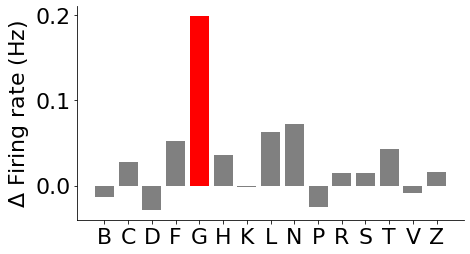

Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0


In [17]:
import matplotlib
font = {'weight' : 'normal',
        'size'   : 22}
matplotlib.rc('font', **font)

for sesID in range(len(Y)):
    yi = Y[sesID]
    xi = completeBinned[sesID]

    respALL = []
    for l in range(15):
        resp = np.mean(np.mean(xi[yi[:,l]==1,:,2:16],axis=-1),axis=0)-np.mean(np.mean(xi[yi[:,l]==0,:,2:16],axis=-1),axis=0)
        #print(resp.shape)
        respALL.append(resp/0.5)
        
    respALL = np.array(respALL)
    #respALL = np.array([r-np.min(r) for r in respALL.T])
    #respALL.shape

    import numpy as np

    # respALL: shape (15, n_neurons)
    E, N = respALL.shape

    max_idx = np.argmax(respALL, axis=0)          # (N,)
    max_val = respALL[max_idx, np.arange(N)]      # (N,)

    # mean/std across elements per neuron
    mu = respALL.mean(axis=0)                     # (N,)
    sd = respALL.std(axis=0, ddof=1) + 1e-12      # (N,)

    z = (max_val - mu) / sd                       # (N,)

    # choose a threshold (e.g., 3 = pretty strict, 4 = very strict)
    z_thresh = 3
    selective_neurons = np.where(z >= z_thresh)[0]

    # results
    winner_element  = max_idx[selective_neurons]
    winner_z        = z[selective_neurons]
    winner_response = max_val[selective_neurons]

    print("Num selective neurons:", len(selective_neurons))
    print("Example (neuron, element, z, max_resp):")
    #for i in range(min(10, len(selective_neurons))):
    #    n = selective_neurons[i]
    #    print(n, winner_element[i], winner_z[i], winner_response[i])
        
    n_elements = respALL.shape[0]
    for n in selective_neurons:
        vals = respALL[:, n]
        pref = np.argmax(vals)

        
        colors = ["gray"] * n_elements
        colors[pref] = "red"

        fig,ax = plt.subplots(figsize=(7, 4))
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.bar(np.arange(n_elements), vals, color=colors)
        
        #plt.xlabel("Element")
        plt.ylabel("$\Delta$ Firing rate (Hz)")
        #plt.title(f"Neuron {n} (preferred element = {uniqueLetters[pref]})")

        plt.xticks(np.arange(n_elements),uniqueLetters)
        plt.tight_layout()
        #plt.savefig('alignedNeuron.png',dpi=200)
        plt.show()      


===== Permutation z-test summary =====

(15, 14, 16)
(15, 14)
Session  0 | Total neurons:   14 | Significant:    2 | Fraction: 0.143


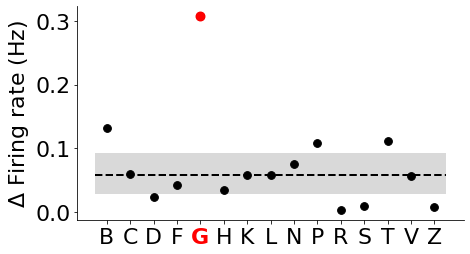

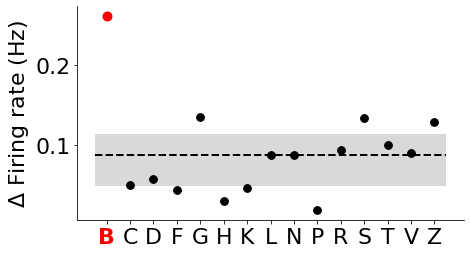

(15, 16, 16)
(15, 16)
Session  1 | Total neurons:   16 | Significant:    0 | Fraction: 0.000
(15, 15, 16)
(15, 15)
Session  2 | Total neurons:   15 | Significant:    0 | Fraction: 0.000
(15, 31, 16)
(15, 31)
Session  3 | Total neurons:   31 | Significant:    3 | Fraction: 0.097


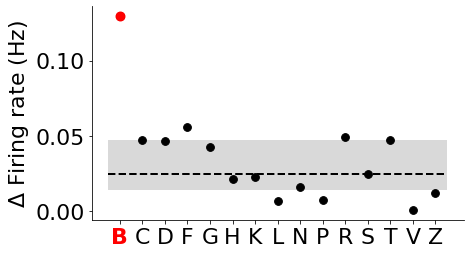

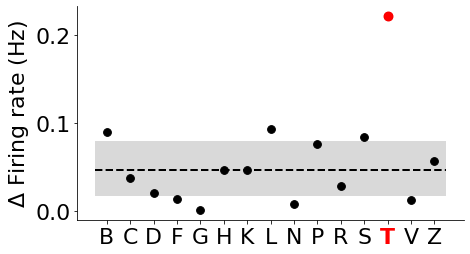

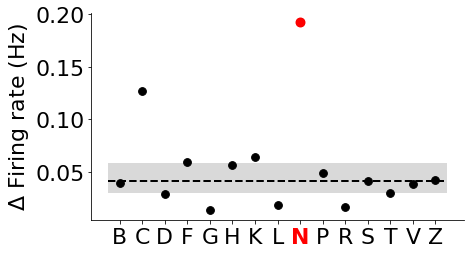

(15, 29, 16)
(15, 29)
Session  4 | Total neurons:   29 | Significant:    4 | Fraction: 0.138


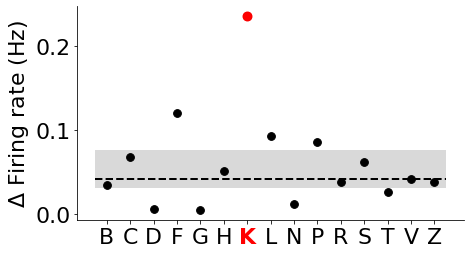

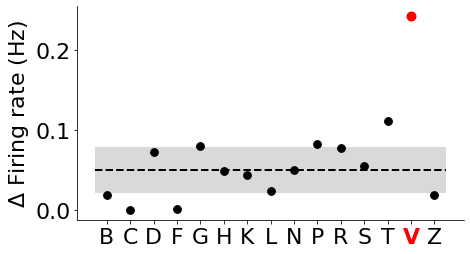

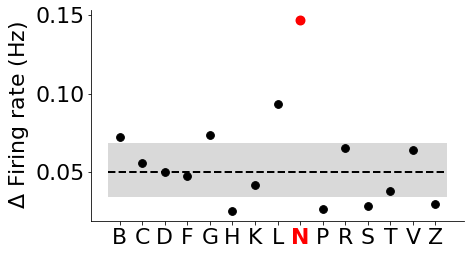

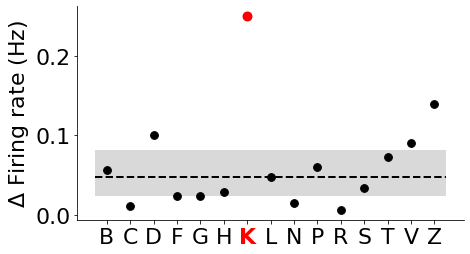

(15, 33, 16)
(15, 33)
Session  5 | Total neurons:   33 | Significant:    2 | Fraction: 0.061


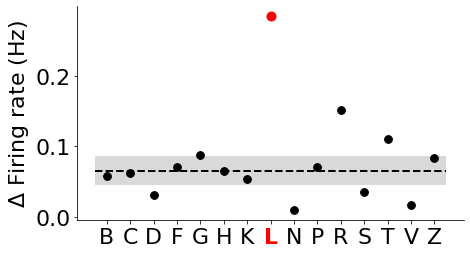

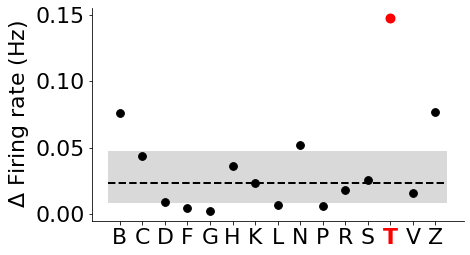

(15, 27, 16)
(15, 27)
Session  6 | Total neurons:   27 | Significant:    1 | Fraction: 0.037


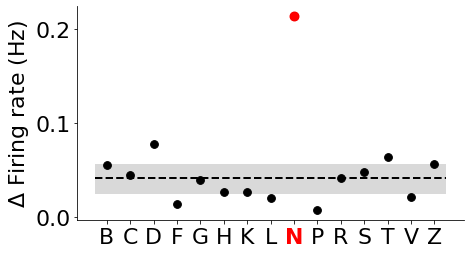

(15, 19, 16)
(15, 19)
Session  7 | Total neurons:   19 | Significant:    1 | Fraction: 0.053


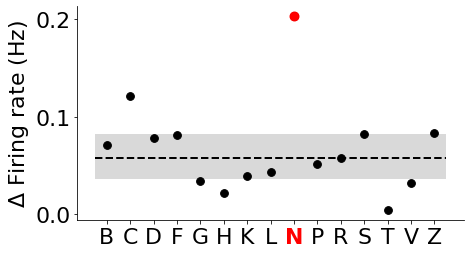

(15, 52, 16)
(15, 52)
Session  8 | Total neurons:   52 | Significant:    3 | Fraction: 0.058


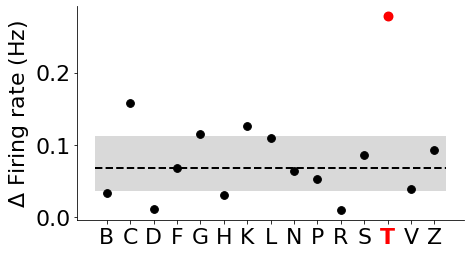

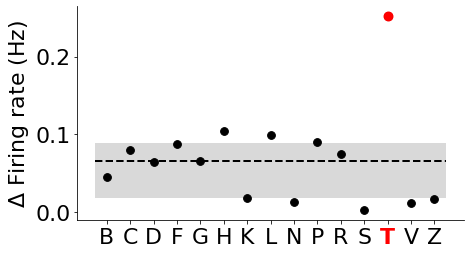

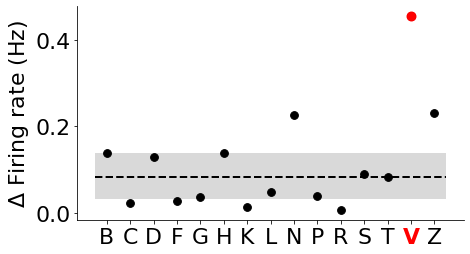

(15, 70, 16)
(15, 70)
Session  9 | Total neurons:   70 | Significant:    7 | Fraction: 0.100


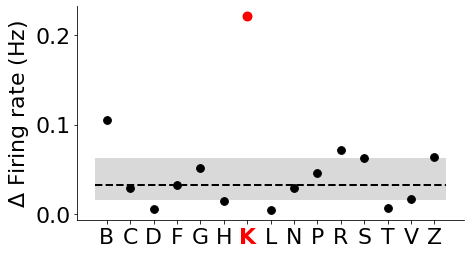

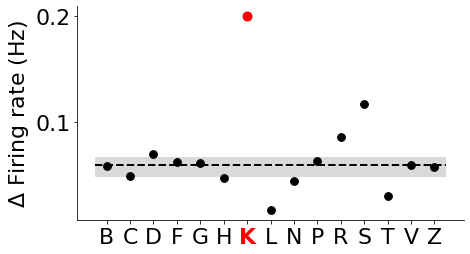

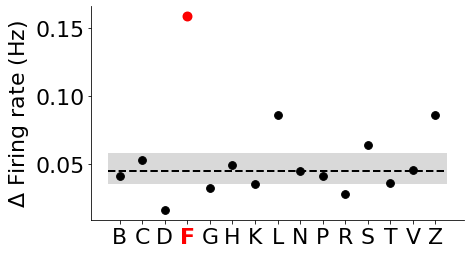

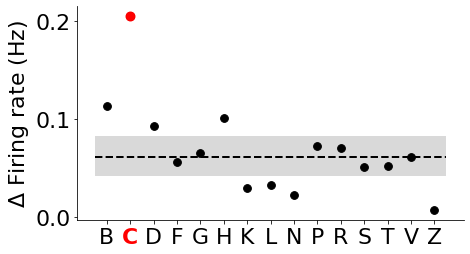

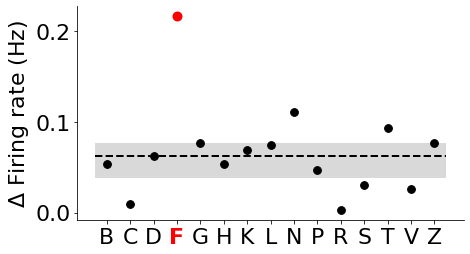

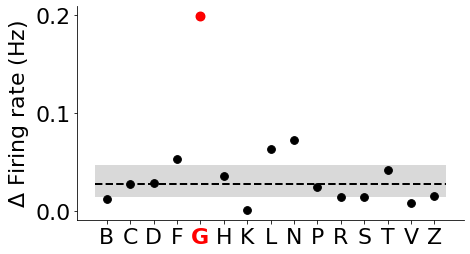

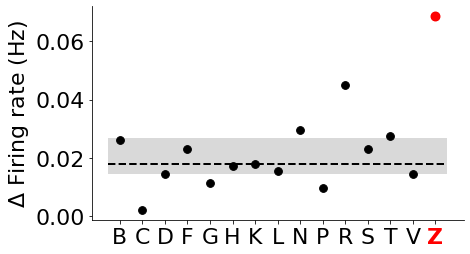

(15, 28, 16)
(15, 28)
Session 10 | Total neurons:   28 | Significant:    1 | Fraction: 0.036


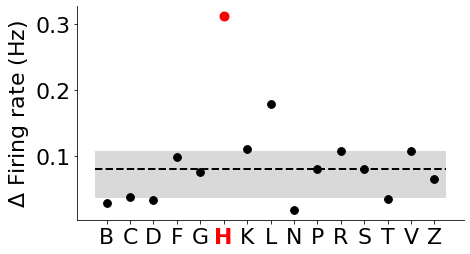

(15, 25, 16)
(15, 25)
Session 11 | Total neurons:   25 | Significant:    0 | Fraction: 0.000
(15, 20, 16)
(15, 20)
Session 12 | Total neurons:   20 | Significant:    1 | Fraction: 0.050


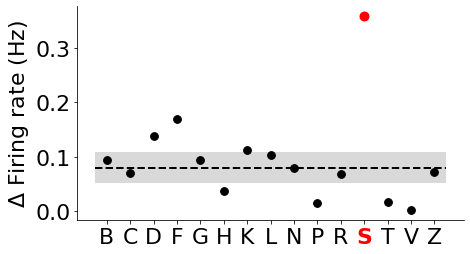

(15, 15, 16)
(15, 15)
Session 13 | Total neurons:   15 | Significant:    0 | Fraction: 0.000
(15, 24, 16)
(15, 24)
Session 14 | Total neurons:   24 | Significant:    0 | Fraction: 0.000
(15, 32, 16)
(15, 32)
Session 15 | Total neurons:   32 | Significant:    1 | Fraction: 0.031


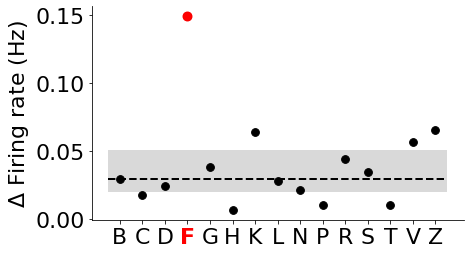

(15, 30, 16)
(15, 30)
Session 16 | Total neurons:   30 | Significant:    1 | Fraction: 0.033


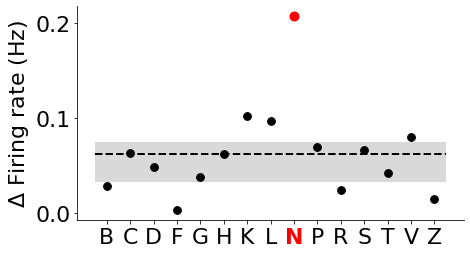

(15, 26, 16)
(15, 26)
Session 17 | Total neurons:   26 | Significant:    1 | Fraction: 0.038


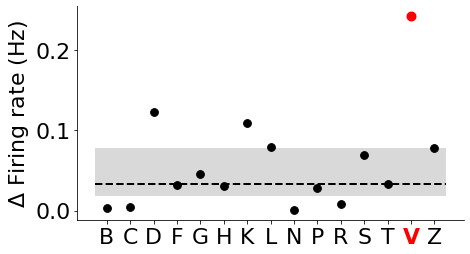

(15, 31, 16)
(15, 31)
Session 18 | Total neurons:   31 | Significant:    1 | Fraction: 0.032


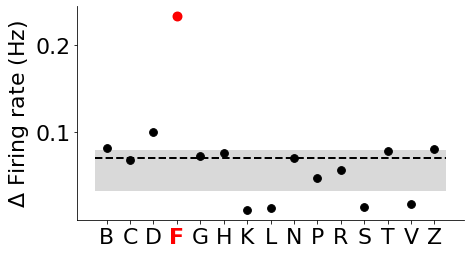

(15, 20, 16)
(15, 20)
Session 19 | Total neurons:   20 | Significant:    1 | Fraction: 0.050


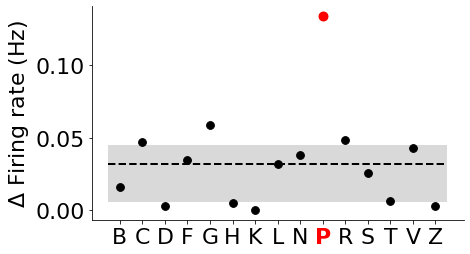

(15, 20, 16)
(15, 20)
Session 20 | Total neurons:   20 | Significant:    4 | Fraction: 0.200


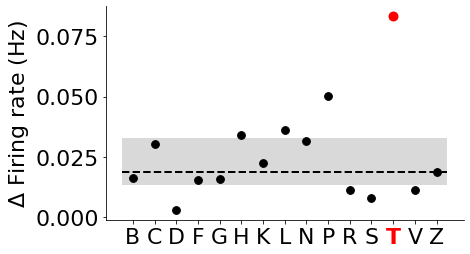

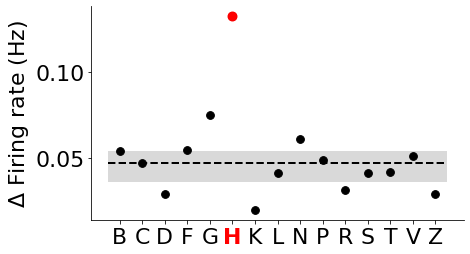

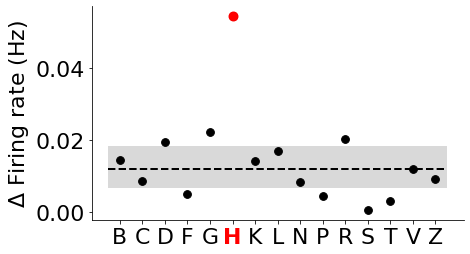

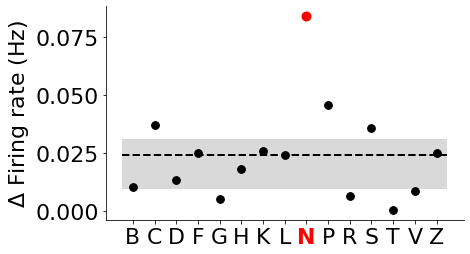

(15, 11, 16)
(15, 11)
Session 21 | Total neurons:   11 | Significant:    0 | Fraction: 0.000
(15, 16, 16)
(15, 16)
Session 22 | Total neurons:   16 | Significant:    2 | Fraction: 0.125


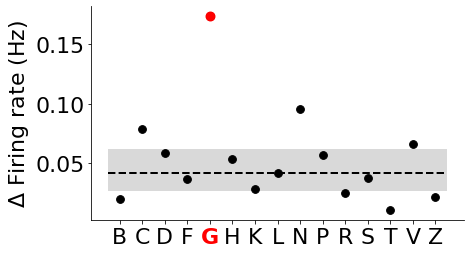

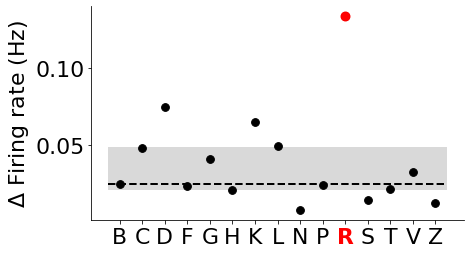

(15, 77, 16)
(15, 77)
Session 23 | Total neurons:   77 | Significant:    5 | Fraction: 0.065


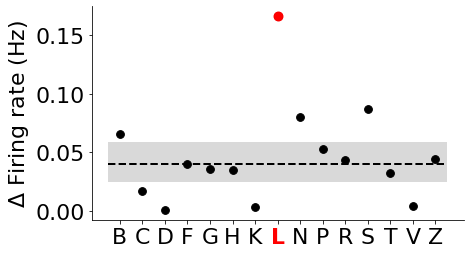

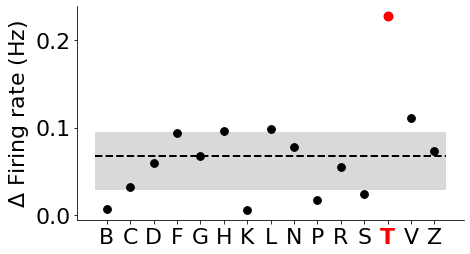

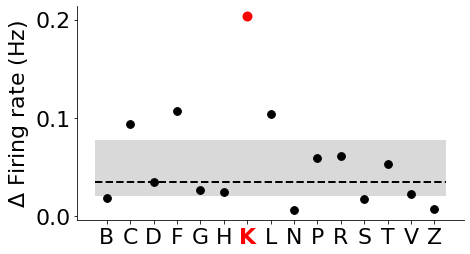

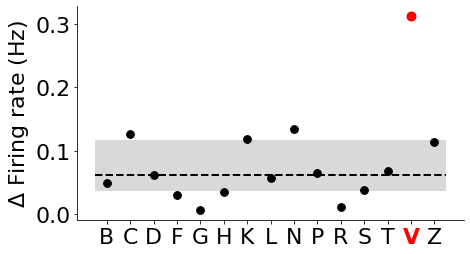

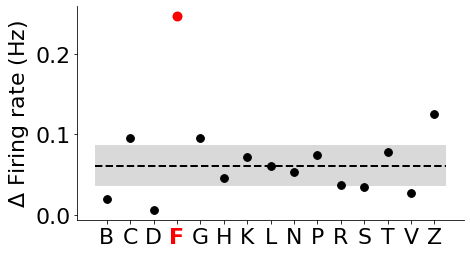

(15, 52, 16)
(15, 52)
Session 24 | Total neurons:   52 | Significant:    3 | Fraction: 0.058


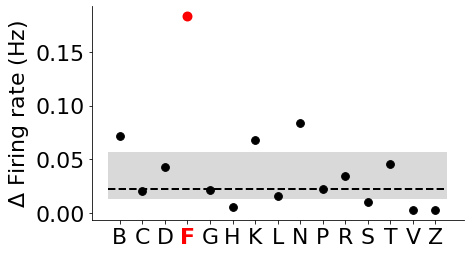

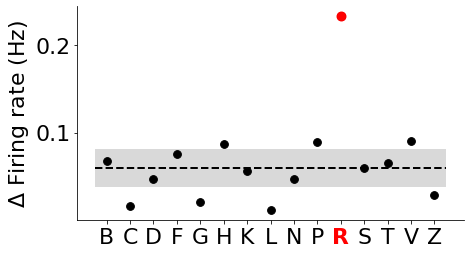

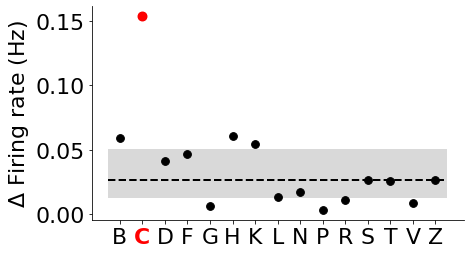

(15, 32, 16)
(15, 32)
Session 25 | Total neurons:   32 | Significant:    2 | Fraction: 0.062


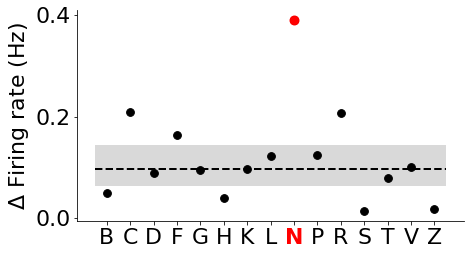

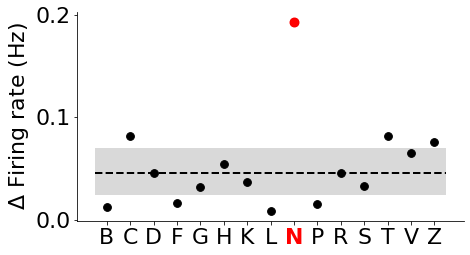

(15, 96, 16)
(15, 96)
Session 26 | Total neurons:   96 | Significant:    8 | Fraction: 0.083


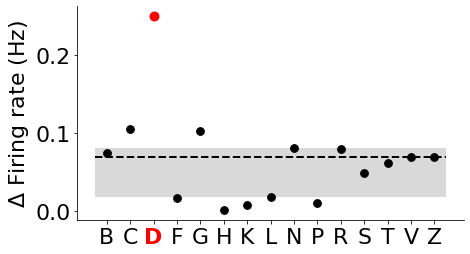

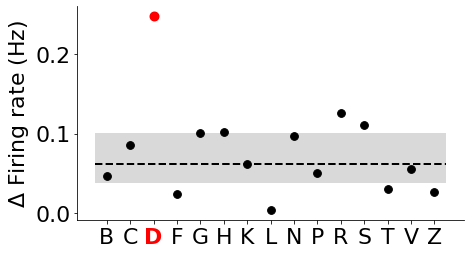

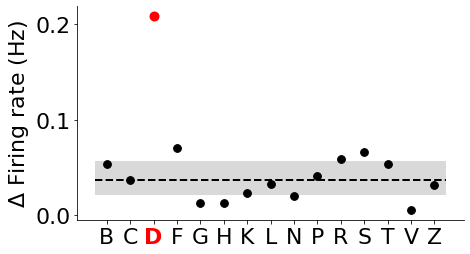

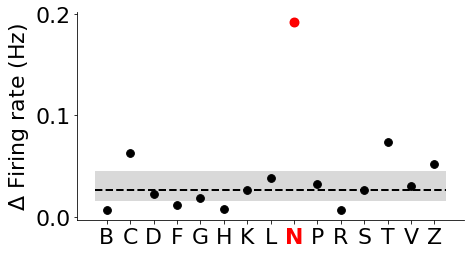

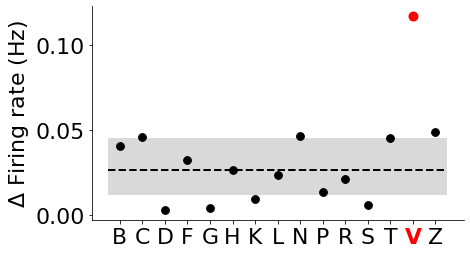

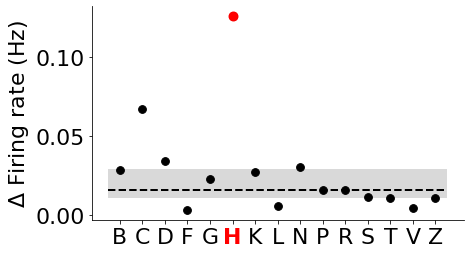

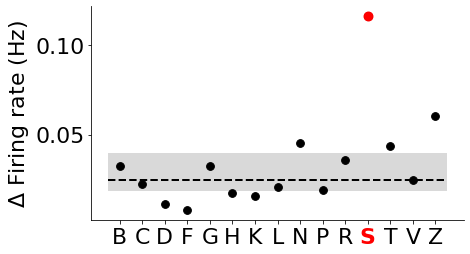

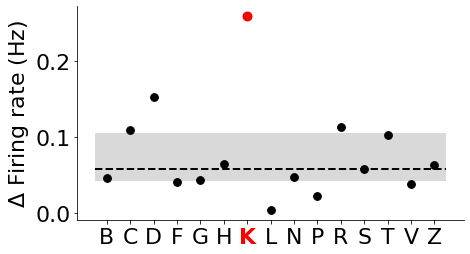

(15, 37, 16)
(15, 37)
Session 27 | Total neurons:   37 | Significant:    1 | Fraction: 0.027


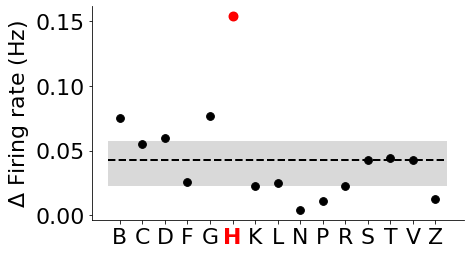

(15, 15, 16)
(15, 15)
Session 28 | Total neurons:   15 | Significant:    1 | Fraction: 0.067


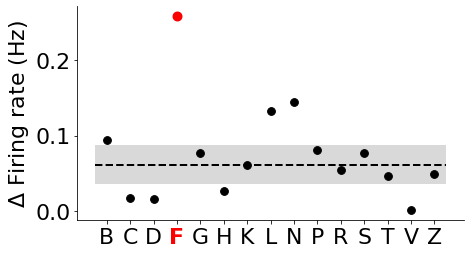

(15, 17, 16)
(15, 17)
Session 29 | Total neurons:   17 | Significant:    0 | Fraction: 0.000
(15, 16, 16)
(15, 16)
Session 30 | Total neurons:   16 | Significant:    2 | Fraction: 0.125


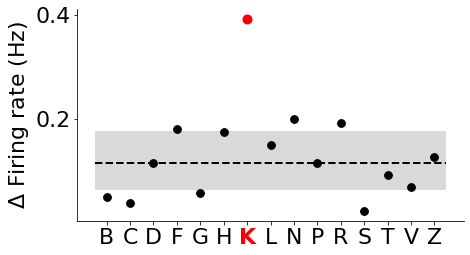

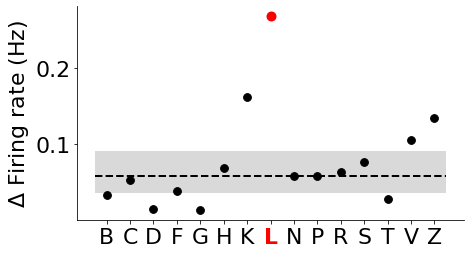

(15, 12, 16)
(15, 12)
Session 31 | Total neurons:   12 | Significant:    2 | Fraction: 0.167


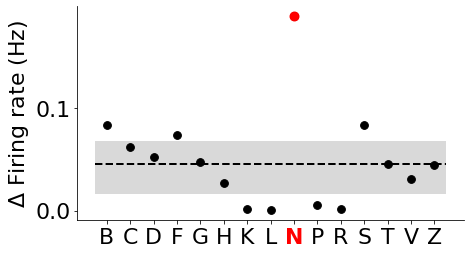

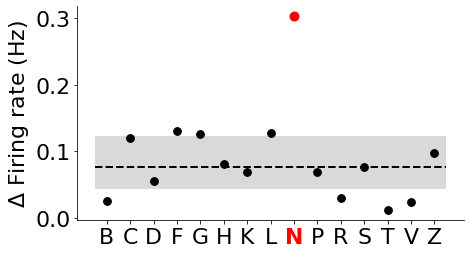

(15, 12, 16)
(15, 12)
Session 32 | Total neurons:   12 | Significant:    2 | Fraction: 0.167


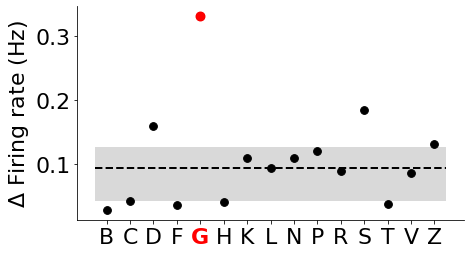

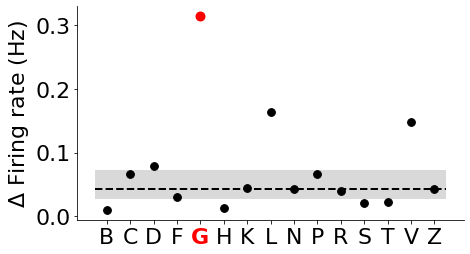

(15, 12, 16)
(15, 12)
Session 33 | Total neurons:   12 | Significant:    1 | Fraction: 0.083


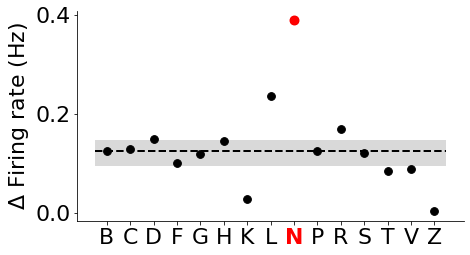

(15, 14, 16)
(15, 14)
Session 34 | Total neurons:   14 | Significant:    1 | Fraction: 0.071


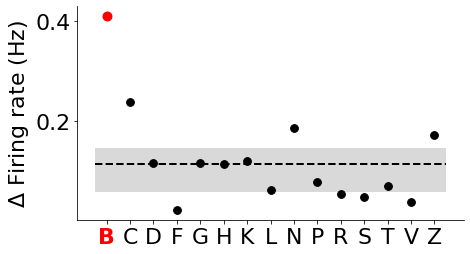


===== Overall =====
Total neurons:     996
Total significant: 64
Overall fraction:  0.064


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

font = {'weight': 'normal', 'size': 22}
matplotlib.rc('font', **font)
# -----------------------
# Core computations
# -----------------------

def compute_respALL(xdat, yi, t0=2, t1=16, bin_width_s=0.5,shuffle=False):
    """
    Compute Δ firing rate (Hz) for each letter.

    xdat: (n_trials, n_neurons, n_timebins)
    yi:   (n_trials, n_letters) typically (n_trials, 15)
    returns: (n_letters, n_neurons)
    """
    n_trials, n_neurons, _ = xdat.shape
    n_letters = yi.shape[1]

    respALL = np.full((n_letters, n_neurons), np.nan)

    # average over time window
    xw = np.mean(xdat[:, :, t0:t1], axis=-1)  # (trials, neurons)

    for l in range(n_letters):
        yic = yi.copy()
        if(shuffle):
            np.random.shuffle(yic[:,l])
        m1 = yic[:, l] == 1
        m0 = yic[:, l] == 0

        # protect against empty splits
        if np.any(m1) and np.any(m0):
            diff = np.abs(np.mean(xw[m1, :], axis=0) - np.mean(xw[m0, :], axis=0))
            respALL[l, :] = diff / bin_width_s

    return respALL

def compute_respALL_trace(xdat, yi, t0=2, t1=16, bin_width_s=0.5):
    """
    Compute Δ firing rate (Hz) for each letter.

    xdat: (n_trials, n_neurons, n_timebins)
    yi:   (n_trials, n_letters) typically (n_trials, 15)
    returns: (n_letters, n_neurons)
    """
    n_trials, n_neurons, _ = xdat.shape
    n_letters = yi.shape[1]

    respALL = np.full((n_letters, n_neurons,t1), np.nan)

    # average over time window
    xw = xdat[:, :, :]  # (trials, neurons)

    for l in range(n_letters):
        m1 = yi[:, l] == 1
        m0 = yi[:, l] == 0

        # protect against empty splits
        if np.any(m1) and np.any(m0):
            diff = np.mean(xw[m1, :], axis=0) - np.mean(xw[m0, :], axis=0)
            respALL[l, :] = diff / bin_width_s

    return respALL


def compute_z(respALL):
    """
    Compute z-score per neuron:
      (max - mean) / std  across letters

    respALL: (n_letters, N)
    returns: (N,)
    """
    max_val = np.nanmax(respALL, axis=0)
    mu = np.nanmean(respALL, axis=0)
    sd = np.nanstd(respALL, axis=0, ddof=1) + 1e-12
    z = (max_val - mu) / sd
    return z


def permutation_test_z(xdat, yi, n_perm=20000, seed=0,
                       t0=2, t1=16, bin_width_s=0.5):
    """
    Run permutation test on z-score.

    Returns:
      respALL_obs (n_letters, N)
      z_obs       (N,)
      z_perm      (n_perm, N)
      pvals       (N,)
    """
    rng = np.random.default_rng(seed)

    # ----- observed
    respALL_obs_trace = compute_respALL_trace(xdat, yi, t0=t0, t1=t1, bin_width_s=bin_width_s)
    respALL_obs = compute_respALL(xdat, yi)
    print(respALL_obs_trace.shape)
    print(respALL_obs.shape)
    z_obs = compute_z(respALL_obs)

    n_letters, N = respALL_obs.shape

    # ----- permutations
    z_perm = np.full((n_perm, N), np.nan)

    for p in range(n_perm):
        yi_perm = yi.copy()

        # permute trials within each letter
        for l in range(n_letters):
            perm_idx = rng.permutation(yi_perm.shape[0])
            yi_perm[:, l] = yi_perm[perm_idx, l]

        respALL_p = compute_respALL(xdat, yi_perm, t0=t0, t1=t1, bin_width_s=bin_width_s)
        z_perm[p, :] = compute_z(respALL_p)

    # ----- p-values (one-sided: high z)
    pvals = np.full(N, np.nan)
    valid = np.isfinite(z_obs)

    if np.any(valid):
        pvals[valid] = (1.0 + np.sum(z_perm[:, valid] >= z_obs[None, valid], axis=0)) / (n_perm + 1.0)

    return respALL_obs, respALL_obs_trace, z_obs, z_perm, pvals


# -----------------------
# Plot helper
# -----------------------

def plot_selective_neurons(respALL, selective_neurons, uniqueLetters, sesID=None,
                           max_plots=None, save_first_session_path="alignedNeuron.png"):
    """
    For each neuron, plot respALL[:, n] with preferred element highlighted,
    plus median and IQR band.

    respALL: (n_letters, N)
    selective_neurons: iterable of neuron indices
    uniqueLetters: list of letter labels length n_letters
    """
    n_elements = respALL.shape[0]

    selective_neurons = np.array(selective_neurons, dtype=int)

    # optional cap (nice if you have tons of significant neurons)
    if max_plots is not None and len(selective_neurons) > max_plots:
        selective_neurons = selective_neurons[:max_plots]
    prefs = []
    for n in selective_neurons:
        vals = respALL[:, n]

        # skip if all-nan
        if not np.any(np.isfinite(vals)):
            continue

        pref = int(np.nanargmax(vals))
        x = np.arange(n_elements)

        # Median and IQR (use nan-safe versions)
        med = np.nanmedian(vals)
        q1 = np.nanpercentile(vals, 25)
        q3 = np.nanpercentile(vals, 75)

        fig, ax = plt.subplots(figsize=(7, 4))

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # Plot dots
        ax.scatter(x, vals, color="k", s=60, zorder=3)

        # Highlight preferred element dot
        ax.scatter(pref, vals[pref], color="red", s=80, zorder=4)

        # Median line
        ax.hlines(
            med,
            xmin=-0.5,
            xmax=n_elements - 0.5,
            colors="black",
            linestyles="--",
            linewidth=2
        )

        # IQR band
        ax.fill_between(
            [-0.5, n_elements - 0.5],
            q1,
            q3,
            color="black",
            alpha=0.15,
            linewidth=0
        )

        ax.set_ylabel(r"$\Delta$ Firing rate (Hz)")

        # X ticks
        ax.set_xticks(x)
        ax.set_xticklabels(uniqueLetters)

        # Make highest-response letter red
        for i, label in enumerate(ax.get_xticklabels()):
            if i == pref:
                label.set_color("red")
                label.set_fontweight("bold")
        plt.tight_layout()

        # Save one example from session 0 (optional)
        #if sesID == 0 and save_first_session_path is not None:
            #plt.savefig(save_first_session_path, dpi=200)

        plt.show()
        
        prefs.append(uniqueLetters[pref])
        
    return prefs


# -----------------------
# Run across sessions
# -----------------------

# Settings
n_perm = 2000
alpha = 0.05
seed = 0

summary = []
all_preferences = []
all_selective = []
print("\n===== Permutation z-test summary =====\n")

for sesID in range(len(Y)):

    yi = Y[sesID]
    xdat = completeBinned[sesID]

    respALL_obs,respALL_obs_trace, z_obs, z_perm, pvals = permutation_test_z(
        xdat, yi,
        n_perm=n_perm,
        seed=seed,
        t0=2, t1=16,
        bin_width_s=0.5
    )

    # significant neurons
    sig_idx = np.where(pvals < alpha)[0]

    n_total = len(z_obs)
    n_sig = len(sig_idx)
    frac = n_sig / n_total if n_total > 0 else np.nan

    summary.append((sesID, n_total, n_sig, frac))

    print(
        f"Session {sesID:2d} | "
        f"Total neurons: {n_total:4d} | "
        f"Significant: {n_sig:4d} | "
        f"Fraction: {frac:.3f}"
    )

    # ---- Plot selective neurons (choose what you mean by "selective")
    selective_neurons = sig_idx  # simplest: significant under permutation test
    all_selective.append(sig_idx)
    if len(selective_neurons) > 0:
        pref_letter = plot_selective_neurons(
            respALL_obs,
            selective_neurons=selective_neurons,
            uniqueLetters=uniqueLetters,   # must be length 15
            sesID=sesID,
            max_plots=20,
            save_first_session_path="alignedNeuron.png"
        )
        all_preferences.extend(pref_letter)


# -----------------------
# Optional: grand summary
# -----------------------

tot_neurons = np.sum([s[1] for s in summary])
tot_sig = np.sum([s[2] for s in summary])

print("\n===== Overall =====")
print(f"Total neurons:     {tot_neurons}")
print(f"Total significant: {tot_sig}")
print(f"Overall fraction:  {tot_sig / tot_neurons:.3f}" if tot_neurons > 0 else "Overall fraction:  nan")

In [16]:
from scipy.stats import binomtest

res = binomtest(64, 996, alpha, alternative="greater")

print(res.pvalue)

0.026503003320196505


In [6]:
directionALL = []
letterALL = []
for sesID in range(len(Y)):
    yi        = Y[sesID]
    xdat      = completeBinned[sesID]
    respALL   = compute_respALL(xdat,yi,shuffle=False)
    direction = []
    letter = []
    for r in respALL.T:
        if(len(r)==len(uniqueLetters)):
            lMax = np.argmax(r)
            letter.append(uniqueLetters[lMax])
            axis = np.zeros(len(uniqueLetters))
            axis[lMax] = 1
            direction.append(np.dot(r,axis)/(np.linalg.norm(r)))
    letterALL.extend(letter)
    directionALL.extend(direction)

directionALL_Shuffle = []
letterALL_Shuffle  = []
for sesID in range(len(Y)):
    yi        = Y[sesID]
    xdat      = completeBinned[sesID]
    respALL   = compute_respALL(xdat,yi,shuffle=True)
    direction = []
    letter = []
    for r in respALL.T:
        if(len(r)==len(uniqueLetters)):
            lMax = np.argmax(r)
            letter.append(uniqueLetters[lMax])
            axis = np.zeros(len(uniqueLetters))
            axis[lMax] = 1
            direction.append(np.dot(r,axis)/(np.linalg.norm(r)))
    letterALL_Shuffle.extend(letter)
    directionALL_Shuffle.extend(direction)

real_stat = np.median(directionALL)

In [7]:
n_perm     = 5000
perm_stats = []

for i in range(n_perm):

    direction_perm = []

    for sesID in range(len(Y)):
        yi        = Y[sesID]
        xdat      = completeBinned[sesID]

        # shuffle labels
        respALL = compute_respALL(xdat, yi, shuffle=True)

        for r in respALL.T:
            if len(r) == len(uniqueLetters):
                lMax = np.argmax(r)
                axis = np.zeros(len(uniqueLetters))
                axis[lMax] = 1
                direction_perm.append(
                    np.dot(r, axis) / np.linalg.norm(r)
                )

    perm_stats.append(np.median(direction_perm))

perm_stats = np.array(perm_stats)
p_value = np.mean(perm_stats >= real_stat)

In [9]:
real_stat

0.5307714945144572

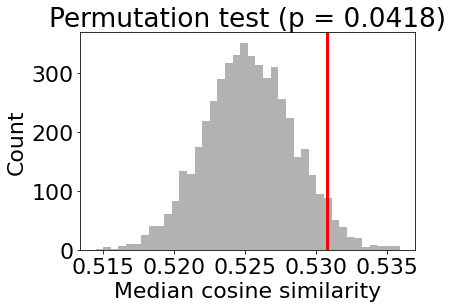

In [8]:
plt.hist(perm_stats, bins=40, color='gray', alpha=0.6)
plt.axvline(real_stat, color='red', linewidth=3)
plt.xlabel("Median cosine similarity")
plt.ylabel("Count")
plt.title(f"Permutation test (p = {p_value:.4f})")
plt.show()

In [23]:
real_stat

0.5307714945144572

In [10]:
from collections import Counter
all_preferences = Counter(all_preferences)

In [11]:
len(all_preferences)

15

In [12]:
len(all_selective)

35

In [13]:
np.save('../selective_neurons.npy',np.array(all_selective,dtype=object))

(15, 70, 16)
(15, 70)
Session  9 | Total neurons:   70 | Significant:    7 | Fraction: 0.100


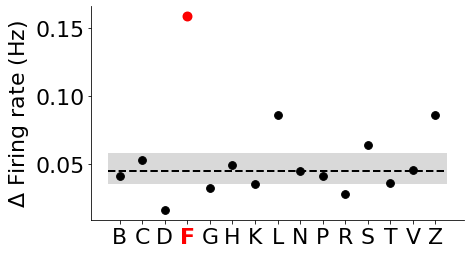

In [22]:
for sesID in [9]:

    yi = Y[sesID]
    xdat = completeBinned[sesID]

    respALL_obs, respALL_obs_trace, z_obs, z_perm, pvals = permutation_test_z(
        xdat, yi,
        n_perm=n_perm,
        seed=seed,
        t0=2, t1=16,
        bin_width_s=0.5
    )

    # significant neurons
    sig_idx = np.where(pvals < alpha)[0]

    n_total = len(z_obs)
    n_sig = len(sig_idx)
    frac = n_sig / n_total if n_total > 0 else np.nan

    summary.append((sesID, n_total, n_sig, frac))

    print(
        f"Session {sesID:2d} | "
        f"Total neurons: {n_total:4d} | "
        f"Significant: {n_sig:4d} | "
        f"Fraction: {frac:.3f}"
    )

    # ---- Plot selective neurons (choose what you mean by "selective")
    selective_neurons = sig_idx  # simplest: significant under permutation test
    selective_neurons = np.array(selective_neurons, dtype=int)[2:3]

    for n in selective_neurons:
        vals = respALL_obs[:, n]

        # skip if all-nan
        if not np.any(np.isfinite(vals)):
            continue

        pref = int(np.nanargmax(vals))
        x = np.arange(n_elements)

        # Median and IQR (use nan-safe versions)
        med = np.nanmedian(vals)
        q1 = np.nanpercentile(vals, 25)
        q3 = np.nanpercentile(vals, 75)

        fig, ax = plt.subplots(figsize=(7, 4))

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # Plot dots
        ax.scatter(x, vals, color="k", s=60, zorder=3)

        # Highlight preferred element dot
        ax.scatter(pref, vals[pref], color="red", s=80, zorder=4)

        # Median line
        ax.hlines(
            med,
            xmin=-0.5,
            xmax=n_elements - 0.5,
            colors="black",
            linestyles="--",
            linewidth=2
        )

        # IQR band
        ax.fill_between(
            [-0.5, n_elements - 0.5],
            q1,
            q3,
            color="black",
            alpha=0.15,
            linewidth=0
        )

        ax.set_ylabel(r"$\Delta$ Firing rate (Hz)")

        # X ticks
        ax.set_xticks(x)
        ax.set_xticklabels(uniqueLetters)

        # Make highest-response letter red
        for i, label in enumerate(ax.get_xticklabels()):
            if i == pref:
                label.set_color("red")
                label.set_fontweight("bold")
        plt.tight_layout()
        plt.show()

In [15]:
xdat.shape

(47, 70, 16)

In [19]:
from collections import Counter
all_preferences = Counter(all_preferences)

/tmp/ipykernel_22995/3133787137.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


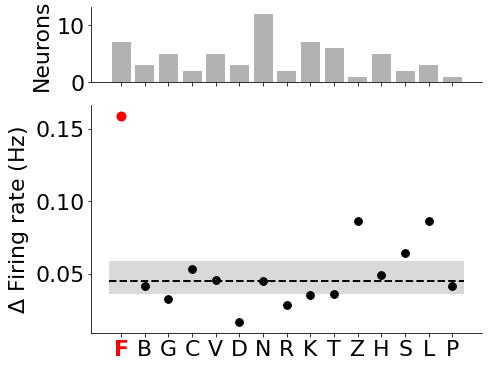

In [23]:
# --- Build counts from Counter ---
ordered_letters = ['F','B','G','C','V','D','N','R','K','T','Z','H','S','L','P']
reorder = np.array([np.where(uniqueLetters==o)[0][0] for o in ordered_letters])
counts = np.array(
    [all_preferences.get(letter, 0) for letter in uniqueLetters[reorder]],
    dtype=int
)

# --- Two vertically stacked plots, shared x (counts on top now) ---
fig, (ax2, ax) = plt.subplots(
    2, 1,
    figsize=(7, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 3], "hspace": 0.15}
)

# =======================
# Top: preference counts
# =======================
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

ax2.bar(x, counts, alpha=0.6,color='gray')

ax2.set_ylabel("Neurons")
ax2.set_ylim(0, max(1, counts.max() * 1.1))


# =======================
# Bottom: tuning plot
# =======================
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

pref = np.argmax(vals)
new_pref = np.where(reorder==pref)[0][0]
ax.scatter(x, vals[reorder], color="k", s=60, zorder=3)
ax.scatter(new_pref, vals[reorder[new_pref]], color="red", s=80, zorder=4)

ax.hlines(
    med,
    xmin=-0.5,
    xmax=n_elements - 0.5,
    colors="black",
    linestyles="--",
    linewidth=2
)

ax.fill_between(
    [-0.5, n_elements - 0.5],
    q1,
    q3,
    color="black",
    alpha=0.15,
    linewidth=0
)

ax.set_ylabel(r"$\Delta$ Firing rate (Hz)")

# =======================
# X ticks (bottom only)
# =======================
ax.set_xticks(x)
ax.set_xticklabels(uniqueLetters[reorder])

# Highlight preferred letter
for i, label in enumerate(ax.get_xticklabels()):
    if i == new_pref:
        label.set_color("red")
        label.set_fontweight("bold")

plt.tight_layout()
#plt.savefig('selective_neurons.svg',dpi=200)
plt.show()

/tmp/ipykernel_22995/3260962152.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


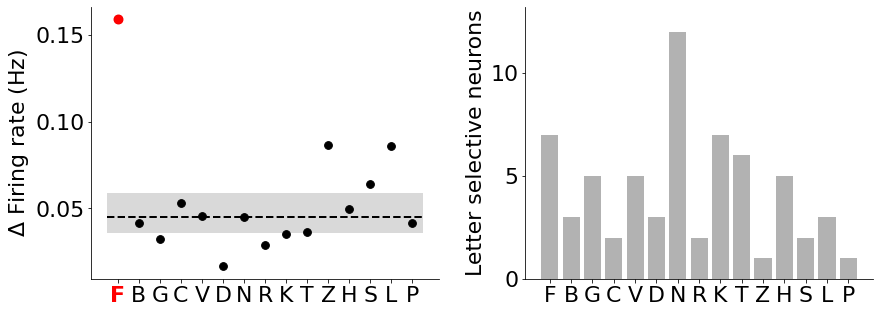

In [34]:
# --- Build counts from Counter ---
ordered_letters = ['F','B','G','C','V','D','N','R','K','T','Z','H','S','L','P']
reorder = np.array([np.where(uniqueLetters==o)[0][0] for o in ordered_letters])
counts = np.array(
    [all_preferences.get(letter, 0) for letter in uniqueLetters[reorder]],
    dtype=int
)

# =======================
# Panel 1: preference counts
# =======================
#fig1, ax_counts = plt.subplots(figsize=(7, 2.5))
fig, (ax_tuning, ax_counts) = plt.subplots(
    1, 2, figsize=(14, 5),
    gridspec_kw={"width_ratios": [2, 2], "wspace": 0.25}
)

ax_counts.spines['top'].set_visible(False)
ax_counts.spines['right'].set_visible(False)

ax_counts.bar(x, counts, alpha=0.6, color='gray')
ax_counts.set_ylabel("Letter selective neurons")
ax_counts.set_ylim(0, max(1, counts.max() * 1.1))
ax_counts.set_xticks(x)
ax_counts.set_xticklabels(uniqueLetters[reorder])
ax_counts.set_yticks([0,5,10])

#plt.tight_layout()
#plt.show()

# =======================
# Panel 2: tuning plot
# =======================
#fig2, ax_tuning = plt.subplots(figsize=(7, 4))

ax_tuning.spines['top'].set_visible(False)
ax_tuning.spines['right'].set_visible(False)

pref = np.argmax(vals)
new_pref = np.where(reorder == pref)[0][0]

ax_tuning.scatter(x, vals[reorder], color="k", s=60, zorder=3)
ax_tuning.scatter(new_pref, vals[reorder[new_pref]], color="red", s=80, zorder=4)

ax_tuning.hlines(
    med, xmin=-0.5, xmax=n_elements - 0.5,
    colors="black", linestyles="--", linewidth=2
)

ax_tuning.fill_between(
    [-0.5, n_elements - 0.5],
    q1, q3,
    color="black", alpha=0.15, linewidth=0
)

ax_tuning.set_ylabel(r"$\Delta$ Firing rate (Hz)")

ax_tuning.set_xticks(x)
ax_tuning.set_xticklabels(uniqueLetters[reorder])

for i, label in enumerate(ax_tuning.get_xticklabels()):
    if i == new_pref:
        label.set_color("red")
        label.set_fontweight("bold")

plt.tight_layout()
plt.savefig('selective_neurons_panel.svg',dpi=200)
plt.show()